## DDIM inversion (initalise with MCPL pretrained)

In [1]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append('/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser')
from torchvision import transforms
from edit_modules.clip import CLIPTextModel
from edit_modules.embed_manager import EmbeddingManager,Embed_control_manager
from diffusers.models.modeling_utils import load_state_dict
from torchvision import transforms as tfms
from PIL import Image
from transformers import CLIPTokenizer
import torch


from diffusers import StableDiffusionCausalControlNetPipeline, Causal_ControlNetModel, UniPCMultistepScheduler,StableDiffusionPipeline
from causal_modules.ddim_modules import *
size = 256

image_transforms = transforms.Compose(
        [
            transforms.Resize((size,size), interpolation=transforms.InterpolationMode.BILINEAR),
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5]),
        ]
        )
original_transforms = transforms.Compose(
        [
            transforms.Resize((size,size), interpolation=transforms.InterpolationMode.BILINEAR),
        ]
        )

tensor_image_transforms = transforms.Compose(
            [
                transforms.ToTensor(),
                transforms.Normalize([0.5], [0.5]),
            ]
        )
        

In [2]:
'''Load pipeline'''


base_model_path = "/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/.cache/huggingface/hub/models--lambdalabs--miniSD-diffusers/snapshots/26ed8a9bfbf76f46a6cf60517dde321f900c44ce"
'''cond_text_contrastive'''

controlnet_path = "../logs/logs_celebahq_simple_all/2025-10-07T14-56-05-controlnet_textcond_constrastive_7attrsgeneration_text_global_after/controlnet-steps-200000.safetensors"
mcpl_embedding_path = "../logs/logs_celebahq_simple_all/2025-10-07T14-56-05-controlnet_textcond_constrastive_7attrsgeneration_text_global_after/learned_embeds-steps-200000.safetensors"

device = torch.device("cuda")
controlnet = Causal_ControlNetModel.from_pretrained(controlnet_path,torch_dtype=torch.float32)

controlnet.eval()
print('training_mode', controlnet.task_cond)
# Load mcpl embedding

prompt = 'a human of @ and * and & and ! and % and $ and #'
presudo_words= '@,*,&,!,%,$,#'
#presudo_words = 'young,female,beard,bald'
presudo_list = presudo_words.split(',')
tokenizer = CLIPTokenizer.from_pretrained(base_model_path,subfolder="tokenizer")
presudo_token_ids = tokenizer.encode(' '.join(presudo_list), add_special_tokens=False)
embed_control_manager_bool = True
if 'image' in controlnet.task_cond:
    embed_control_manager_bool = False
text_encoder = load_mcpl_embeddings(base_model_path,tokenizer,mcpl_embedding_path,presudo_token_ids,embed_control=embed_control_manager_bool)

pipe = StableDiffusionCausalControlNetPipeline.from_pretrained(
    base_model_path, controlnet=controlnet,text_encoder=text_encoder ,torch_dtype=torch.float32
)
# pipe.scheduler = DDIMScheduler.from_config(
#     pipe.scheduler.config
# )
pipe.scheduler = DDIMScheduler(beta_start=0.00085, beta_end=0.012, beta_schedule="scaled_linear", clip_sample=False, set_alpha_to_one=False)

pipe.safety_checker = None
pipe.requires_safety_checker = False
#pipe.load_mcpl_inversion(mcpl_embedding_path)


# memory optimization.
pipe = pipe.to(device)

Skipping initialization on meta device.
Skipping initialization on meta device.
training_mode generation_text_global_after


/home/jovyan/fcvm-data-volume/kzzr229/miniconda3/envs/mcpl/lib/python3.8/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Loaded textual inversion embedding for 256.
Loaded textual inversion embedding for 258.
Loaded textual inversion embedding for 259.
Loaded textual inversion embedding for 260.
Loaded textual inversion embedding for 261.
Loaded textual inversion embedding for 265.
Loaded textual inversion embedding for 287.
load embedding control


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

An error occurred while trying to fetch /home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/.cache/huggingface/hub/models--lambdalabs--miniSD-diffusers/snapshots/26ed8a9bfbf76f46a6cf60517dde321f900c44ce/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/.cache/huggingface/hub/models--lambdalabs--miniSD-diffusers/snapshots/26ed8a9bfbf76f46a6cf60517dde321f900c44ce/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch /home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/.cache/huggingface/hub/models--lambdalabs--miniSD-diffusers/snapshots/26ed8a9bfbf76f46a6cf60517dde321f900c44ce/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/.cache/huggingface/hub/models--lambdalabs--miniSD-diffusers/snapshots/26ed8a9bfbf76

In [3]:
'''from training set'''
import random
import pandas as pd
from torchvision.datasets import CelebA
from edit_modules.load_celebahq import CelebAHQ
def dataset_load_path(data_root,dataset,split='train'):
    data_dir = data_root
    data = CelebAHQ(root=data_dir, split=split, transform=None, download=False)
    num_images = len(data)
    if 'simple' in dataset:
                selected_item = ['Smiling','Eyeglasses','Mouth_Slightly_Open','Male','Bald','Wearing_Lipstick','Wearing_Hat']
    elif 'complex' in dataset:
        pass
    else:
        AssertionError('no such {} dataset'.format(dataset))
    attribute_ids = [data.attr_names.index(attr) for attr in selected_item]
    metrics = {attr: torch.as_tensor(data.attr[:, attr_id], dtype=torch.float32) for attr, attr_id in zip(selected_item, attribute_ids)}

    attrs = torch.cat([metrics[attr].unsqueeze(1)
                            for attr in selected_item], dim=1)
    imglabel= attrs
    possible_values = {attr: torch.unique(values, dim=0) for attr, values in metrics.items()}
    
    img_id = random.randint(0,num_images)
    return data,imglabel,num_images

#img_path = '/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/dataset/causal_data/pendulum/test/a_-1_128_4_12.png'
data,imglabel,num_images = dataset_load_path(data_root='/home/jovyan/fcvm-data-volume/kzzr229/workspace/counterfactual-benchmark/datasets/',dataset=controlnet.dataset,split='test')

tensor([[1., 0., 1., 0., 0., 1., 0.]])


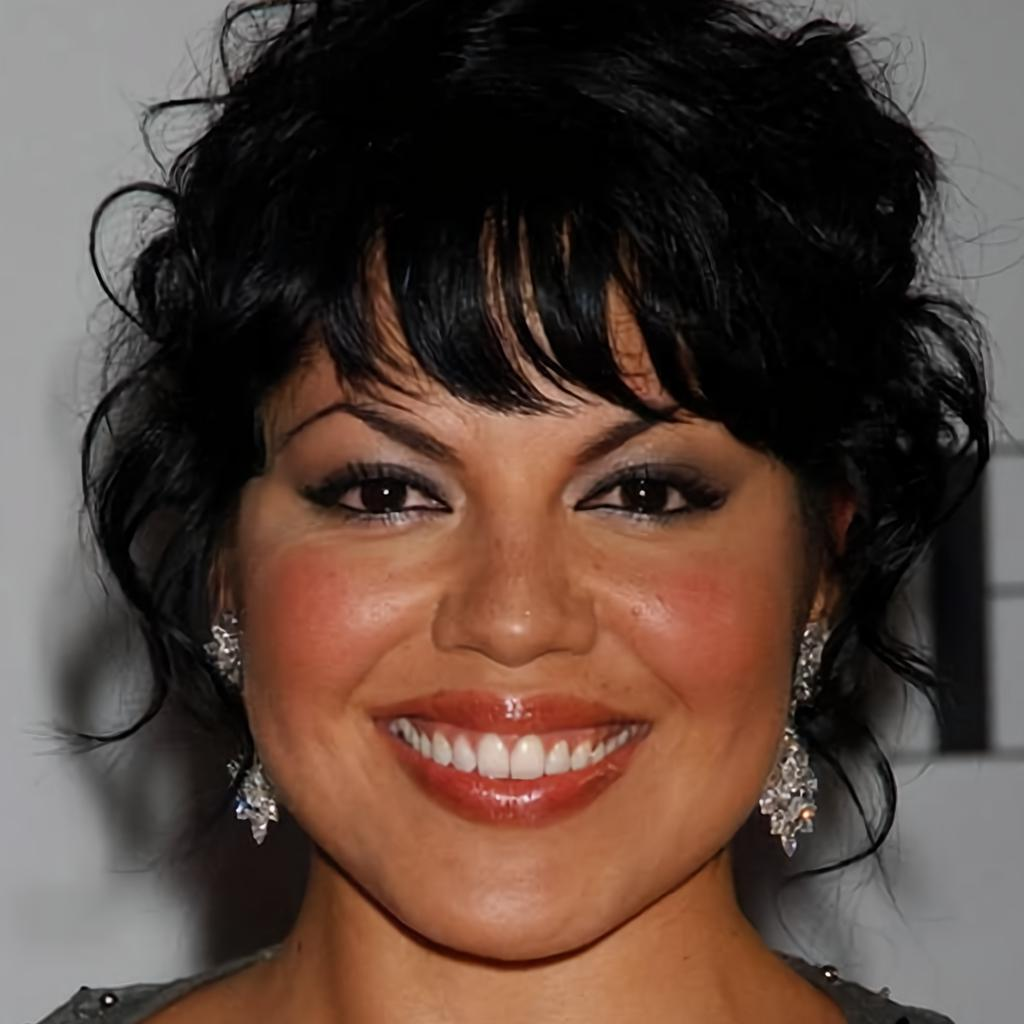

In [14]:
# paper image id (190,8385,2457,2184,3627,5694)
# female (8385,3393,6942)
# valid (79,145,17,18,712)
# ablation (test2,test190,valid23,test25)
# limitation (test2,test357)
# Pressure test (test8951,test1002)
img_id = random.randint(0,num_images)
img_id=63
img,label = data[img_id][0],imglabel[img_id].unsqueeze(0)
print(label)
img

50it [00:05,  9.97it/s]
50it [00:05,  9.98it/s]
50it [00:05,  9.98it/s]


save imgs in ./intervention_variable2.png


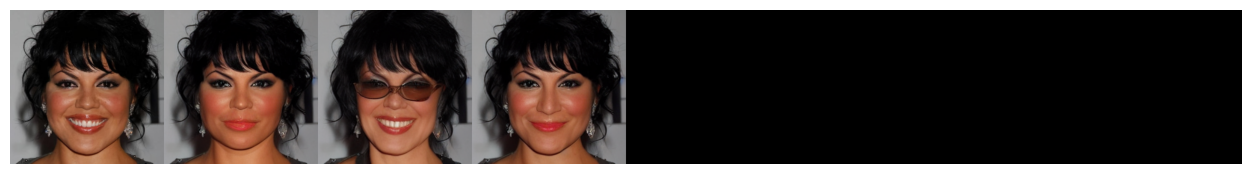

In [17]:
# Prompt2Prompt
from copy import deepcopy
input_image = img
if not input_image.mode == "RGB":
    input_image = image.convert("RGB")

original_img = input_image.copy()
original_img = original_transforms(original_img)
image = image_transforms(input_image) 

# PNP+direct inversion
# do intervention 
inter_value = 1- label.clone().squeeze()


# backup_pipe = deepcopy(pipe)
set_guidance_scale  = 1.5
num_steps = 50      
s_step = 0
invert_guidance_scale=1.0
# False use the normal DDIM 
blend_word = True
# start_blend=0.2, th=(.3, .3)
image_lists = [np.asarray(original_img)]
disentangle= True
#final_im,inverted_latents,_,uncond_embeddings = P2P_editing(pipe, image.unsqueeze(0).repeat(4, 1, 1, 1),text_label,prompt,presudo_list,num_steps = num_steps,invert_guidance_scale=invert_guidance_scale,set_guidance_scale  = set_guidance_scale,intervention_indx=1,intervention_values=inter_value[1],return_PIL=True,blend_word=blend_word)
for inter_id in range(0,3,1):
#for inter_id in [1]:
    images = []
    #inter_value  = -1   
    s_step = 0

    DSCM_labels = label.clone()

    # Set attribute `inter_id` to its complemented value, per sample
    DSCM_labels[:, inter_id] = inter_value[inter_id]

    # If we're intervening on attribute 0, enforce a dependency:
    # attr2 follows the (complemented) value of attr0, per sample.
    if inter_id == 0:
        DSCM_labels[:, 2] = inter_value[0]

    DSCM_labels = DSCM_labels.unsqueeze(2).to(pipe.device)

    # if inter_id ==1:
    #     blend_params = {'start_blend':0.0,'th':(0.65,0.0)}
    #     cross_replace_steps,self_replace_steps = 0.0,0.0
    # else:
        
    #     blend_params = {'start_blend':0.0,'th':(0.1,0.0)}
    #     cross_replace_steps,self_replace_steps = 0.0,0.0
    blend_params = {'start_blend':0.0,'th':(0.1,0.0)}
    cross_replace_steps,self_replace_steps = 0.0,0.0
    
    interved_image,inverted_latents,_,uncond_embeddings = P2P_editing(pipe, image.unsqueeze(0),
                                                        label.clone(),prompt,presudo_list,
                                                        num_steps = num_steps,invert_guidance_scale=invert_guidance_scale,
                                                        set_guidance_scale  = set_guidance_scale,intervention_indx=inter_id,
                                                        intervention_values=inter_value[inter_id],return_PIL=True,
                                                        blend_word=blend_word,blend_params=blend_params,
                                                        disentangle=disentangle,
                                                        cross_replace_steps=cross_replace_steps,self_replace_steps=self_replace_steps,DSCM_labels=DSCM_labels,
                                                        return_recons_counter = True )
    image_lists.append(np.asarray(interved_image[-1]))
          
    
output='./'
save_path = os.path.join(output,'intervention_variable{}.png'.format(inter_id))
save_images_grid([image_lists],(1,8),save_path)
print('save imgs in {}'.format(save_path))



In [68]:
import os
save_path = '../outputs/datasets/benchmark/P2P{}/{}'.format(blend_word,img_id)
os.makedirs(save_path, exist_ok=True)

# Resize and save each image
for i, img in enumerate(tqdm(image_lists, desc="Resizing and saving")):
    # Convert to PIL image
    pil_img = Image.fromarray(img)
    # pil_img.save(os.path.join(save_path, f"{i}.png"))
    # Resize to 64×64
    resized_img = pil_img.resize((64, 64), Image.BICUBIC)
    resized_img = resized_img.resize((207, 207), Image.BICUBIC)
    # Save as PNG
    resized_img.save(os.path.join(save_path, f"{i}.png"))


Resizing and saving: 100%|██████████| 2/2 [00:00<00:00, 28.35it/s]


In [29]:
imglabel[:5].unsqueeze(0)

tensor([[[1., 0., 1., 0., 0., 1., 0.],
         [0., 0., 0., 1., 0., 0., 0.],
         [0., 0., 1., 0., 0., 1., 0.],
         [0., 0., 1., 0., 0., 1., 0.],
         [1., 0., 1., 1., 1., 0., 0.]]])

tensor([[1., 0., 1., 0., 0., 1., 0.]])


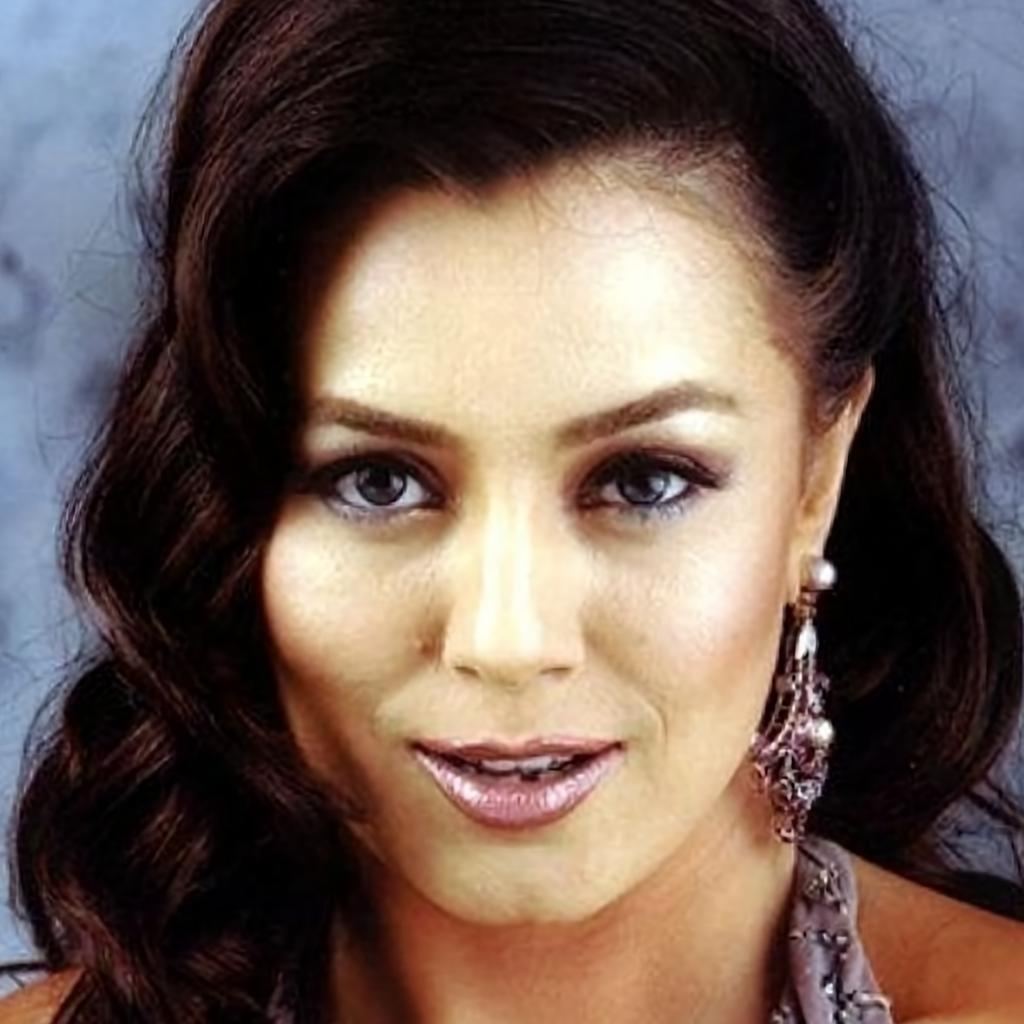

In [13]:
# paper image id (190,8385,2457,2184,3627,5694)
# female (8385,3393,6942)
# valid (79,145,17,18,712)
img_id = random.randint(0,num_images)
img_id=0
img,label = data[img_id][0],imglabel[img_id].unsqueeze(0)
print(label)
img

100%|██████████| 100/100 [00:05<00:00, 19.43it/s]


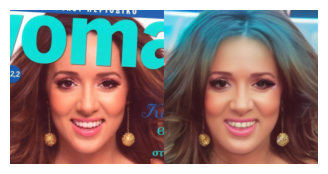

In [21]:
# Null textual inversion
from copy import deepcopy
from causal_modules.p2p_edits.attention_control import register_attention_control_controlnet
img,label = data[img_id][0],imglabel[img_id].unsqueeze(0)
image = img
if not image.mode == "RGB":
    image = image.convert("RGB")

original_img = image.copy()
original_img = original_transforms(original_img)
condition_image = image.copy()
image = image_transforms(image) 

# backup_pipe = deepcopy(pipe)
set_guidance_scale  = 1.0
num_steps = 100      
s_step = 0
invert_guidance_scale=1.0
# False use the normal DDIM 
null_optimization = False
register_attention_control_controlnet(pipe, None)
final_im,inverted_latents,_,uncond_embeddings = ddim_editing(pipe, image.unsqueeze(0),label.clone(),prompt,num_steps = num_steps,invert_guidance_scale=invert_guidance_scale,set_guidance_scale  = set_guidance_scale,intervention_indx=None,intervention_values=None,return_PIL=True,null_optimization=null_optimization)
        
to_pil =  transforms.ToPILImage()
save_images_grid([[original_img, final_im[0]]],(1,2),None)


100%|██████████| 100/100 [00:06<00:00, 16.39it/s]


save imgs in ./intervention_variable2.png


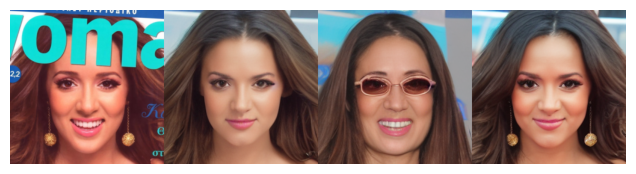

In [22]:
# do intervention 
blend_word = False
#disentanglement using
inter_value = 1- label.clone().squeeze()
# if int(label.squeeze()[0].item()) == 0:
#     inter_value[0]=-1.0

image_lists = [np.asarray(original_img)]

disentangle = True
num_edit = 3
for inter_id in range(0,num_edit,1):
    images = []
    #inter_value  = -1
    # Clone labels for this intervention
    DSCM_labels = label.clone()

    # Set attribute `inter_id` to its complemented value, per sample
    DSCM_labels[:, inter_id] = inter_value[inter_id]

    # If we're intervening on attribute 0, enforce a dependency:
    # attr2 follows the (complemented) value of attr0, per sample.
    if inter_id == 0:
        DSCM_labels[:, 2] = inter_value[0]


    interved_image,causal_cond = sample(
        pipe,
        prompt,
        start_step=s_step,
        start_latents=inverted_latents[-(s_step + 1)].clone(),
        guidance_scale=1.5,
        num_inference_steps=num_steps,
        num_images_per_prompt=1,
        negative_prompt=None,
        device=device,
        controlnet_image=None,
        intervention_indx=inter_id,
        intervention_values=inter_value[inter_id],
        label=DSCM_labels.clone(),
        return_PIL = True,
        disentangle= disentangle,
        uncond_embeddings=None,
    )
    #print(causal_cond)
    image_lists.append(np.asarray(interved_image[0]))
output='./'
save_path = os.path.join(output,'intervention_variable{}.png'.format(inter_id))
save_images_grid([image_lists],(1,num_edit+1),save_path)
print('save imgs in {}'.format(save_path))

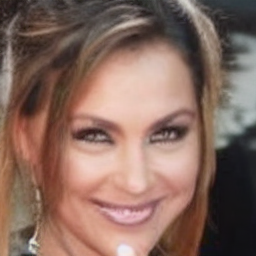

In [ ]:
Image.fromarray(image_lists[1])

In [10]:
import os
save_path = '../outputs/datasets/motivational/P2P{}/{}'.format(blend_word,img_id)
os.makedirs(save_path, exist_ok=True)

# Resize and save each image
for i, img in enumerate(tqdm(image_lists, desc="Resizing and saving")):
    # Convert to PIL image
    pil_img = Image.fromarray(img)
    # pil_img.save(os.path.join(save_path, f"{i}.png"))
    # Resize to 64×64
    resized_img = pil_img.resize((64, 64), Image.BICUBIC)
    resized_img = resized_img.resize((207, 207), Image.BICUBIC)
    # Save as PNG
    resized_img.save(os.path.join(save_path, f"{i}.png"))


Resizing and saving: 100%|██████████| 6/6 [00:00<00:00, 36.26it/s]


In [56]:
import torch
from torchvision import transforms
from PIL import Image
from tqdm import tqdm
import os
import cv2

def find_top5_image_ids_batch(data, selected_img_dir, device='cuda'):
    # 加载所有要比对的输入图片
    selected_imgs = []
    img_names = []
    
    transform_input = transforms.Compose([
        transforms.Resize((64, 64)),    # Resize到64x64
        transforms.ToTensor(),          # (C,H,W)，范围[0,1]
    ])
    
    for img_name in sorted(os.listdir(selected_img_dir)):
        img_path = os.path.join(selected_img_dir, img_name)
        img = cv2.imread(img_path)
        if img is None:
            print(f"Warning: Cannot read image {img_path}, skip.")
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        input_img = Image.fromarray(img)
        input_tensor = transform_input(input_img)
        selected_imgs.append(input_tensor)
        img_names.append(img_name)
    print(img_names)
    # 把选中图片堆成一个 batch
    input_batch = torch.stack(selected_imgs).to(device)  # (N,C,H,W)

    # 加载CelebA所有图，统一处理成 batch
    celebA_tensors = []
    transform_celeba = transforms.Compose([
        transforms.CenterCrop(150),
        transforms.Resize((64, 64)),
        transforms.ToTensor(),
    ])
    
    for idx in tqdm(range(len(data)), desc="Loading CelebA"):
        celebA_img, _ = data[idx]
        celebA_img = transform_celeba(celebA_img)
        celebA_tensors.append(celebA_img)
    
    celebA_batch = torch.stack(celebA_tensors).to(device)  # (M,C,H,W)

    # 计算每一张输入图片到CelebA所有图的距离
    results = {}
    for i, input_tensor in enumerate(input_batch):
        input_expand = input_tensor.unsqueeze(0).expand(celebA_batch.size(0), -1, -1, -1)
        diff = celebA_batch - input_expand  # (M,C,H,W)
        dists = (diff ** 2).sum(dim=(1,2,3)).sqrt()  # 正确地计算batch-wise L2距离
        top5_dist, top5_idx = torch.topk(dists, k=5, largest=False)

        results[img_names[i]] = list(zip(top5_idx.tolist(), top5_dist.tolist()))
    
    return results

selected_img_dir = "/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/dataset/celeA_selected_images/"
results = find_top5_image_ids_batch(data, selected_img_dir)

for img_name, top5 in results.items():
    print(f"\nImage: {img_name}")
    for rank, (idx, dist) in enumerate(top5):
        print(f"  Top-{rank+1}: Image ID {idx}, Distance {dist:.4f}")


libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error


['1.png', '10.png', '11.png', '2.png', '3.png', '4.png', '5.png', '6.png', '7.png', '8.png', '9.png']


Loading CelebA: 100%|██████████| 19962/19962 [00:26<00:00, 765.62it/s]



Image: 1.png
  Top-1: Image ID 2184, Distance 3.0220
  Top-2: Image ID 13187, Distance 14.2842
  Top-3: Image ID 5880, Distance 14.3452
  Top-4: Image ID 5895, Distance 14.8447
  Top-5: Image ID 6409, Distance 15.1976

Image: 10.png
  Top-1: Image ID 273, Distance 3.1274
  Top-2: Image ID 8824, Distance 17.9602
  Top-3: Image ID 1319, Distance 18.3726
  Top-4: Image ID 14465, Distance 18.9987
  Top-5: Image ID 16251, Distance 19.1396

Image: 11.png
  Top-1: Image ID 3, Distance 14.1830
  Top-2: Image ID 16523, Distance 15.0455
  Top-3: Image ID 3887, Distance 15.5813
  Top-4: Image ID 2314, Distance 16.1583
  Top-5: Image ID 59, Distance 16.3270

Image: 2.png
  Top-1: Image ID 2457, Distance 2.8928
  Top-2: Image ID 10505, Distance 18.7902
  Top-3: Image ID 14330, Distance 18.9838
  Top-4: Image ID 4945, Distance 19.2089
  Top-5: Image ID 8098, Distance 19.4329

Image: 3.png
  Top-1: Image ID 3393, Distance 2.6676
  Top-2: Image ID 13672, Distance 19.2269
  Top-3: Image ID 13696, Dist

In [21]:
import cv2

img = cv2.imread('/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/dataset/celeA_selected_images/1.png')
img.shape

libpng warning: iCCP: CRC error


(207, 207, 3)

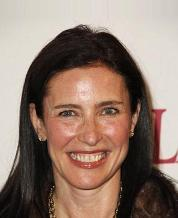

In [59]:

data[6942][0]

  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [00:03<00:00, 14.87it/s]


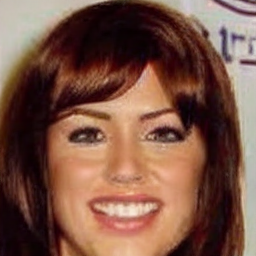

In [51]:
# try replace word
#prompt =  'orange @ and red * and black & and black !'
new_prompt = 'a human of @ and * and & and !'
input_ids = tokenizer(new_prompt,
                        padding="max_length",
                        truncation=True,
                        max_length=tokenizer.model_max_length,
                        return_tensors="pt",
                    ).input_ids[0].to(device)

if input_ids.dim() ==1:
    input_ids=input_ids.unsqueeze(0)

start_latents = torch.randn(1, 4, 32, 32, device=device)
start_latents *= pipe.scheduler.init_noise_sigma
final_im = sample(
        pipe,
        new_prompt,
        start_step=0,
        start_latents=start_latents,
        #start_latents=inverted_latents[-(0 + 1)][None],
        guidance_scale=7.5,
        num_inference_steps=50,
        num_images_per_prompt=1,
        negative_prompt=None,
        device=device,
        controlnet_image=None,
        intervention_indx=None,
        intervention_values=None,
        label=torch.tensor([0,0,1,0],dtype=torch.float32).unsqueeze(0),
        return_PIL=True
    )[0]

final_im

# Reversibility

tensor([[1., 0., 0., 0., 0., 1., 0.]])


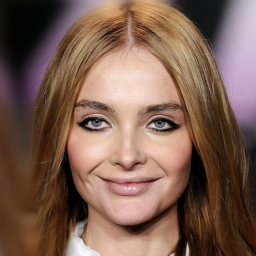

In [59]:
# paper image id (190,8385,2457,2184,3627,5694)
# female (8385,3393,6942)
# valid (79,145,17,18,712)
# ablation (test2,test190,valid23,test25)
# limitation (test2,test357)
# Pressure test (test8951,test1002)
img_id = random.randint(0,num_images)
img_id=5
img,label = data[img_id][0],imglabel[img_id].unsqueeze(0)
print(label)

from copy import deepcopy
input_image = img
if not input_image.mode == "RGB":
    input_image = image.convert("RGB")

original_img = input_image.copy()
original_img = original_transforms(original_img)
image = image_transforms(input_image) 
original_img

In [60]:
import numpy as np

def compos_rever(img_list):
    input_i = img_list[0].astype(np.float32)
    recons_i = img_list[1].astype(np.float32)
    recover_i = img_list[3].astype(np.float32)

    # Compute L1 distance between input and reconstruction
    compos = np.mean(np.abs(input_i - recons_i))

    # Compute L1 distance between input and recovered image
    rever = np.mean(np.abs(input_i - recover_i))

    print(f"Composition (L1): {compos:.4f}/{compos/255.0:.4f}")
    print(f"Reversibility (L1): {rever:.4f}/{rever/255.0:.4f}")


50it [00:05,  9.97it/s]
50it [00:05,  9.97it/s]


Composition (L1): 5.9015/0.0231
Reversibility (L1): 10.4622/0.0410


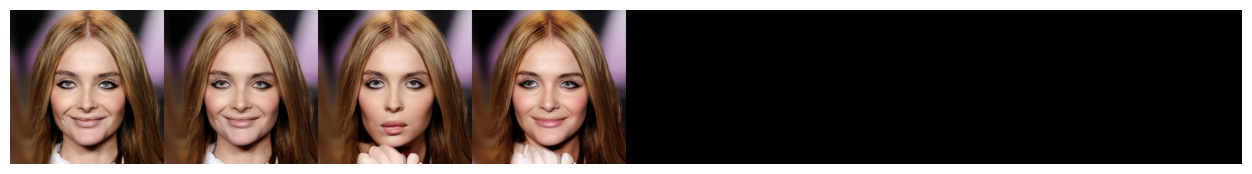

In [61]:
# PNP+direct inversion
# do intervention 
inter_value = 1- label.clone().squeeze()


# backup_pipe = deepcopy(pipe)
set_guidance_scale  = 1.5
num_steps = 50      
s_step = 0
invert_guidance_scale=1.0
# False use the normal DDIM 
blend_word = True
# start_blend=0.2, th=(.3, .3)
image_lists = [np.asarray(original_img)]
disentangle= True
#final_im,inverted_latents,_,uncond_embeddings = P2P_editing(pipe, image.unsqueeze(0).repeat(4, 1, 1, 1),text_label,prompt,presudo_list,num_steps = num_steps,invert_guidance_scale=invert_guidance_scale,set_guidance_scale  = set_guidance_scale,intervention_indx=1,intervention_values=inter_value[1],return_PIL=True,blend_word=blend_word)
inter_id = 0
#for inter_id in [1]:
images = []
#inter_value  = -1   
s_step = 0
DSCM_labels = label.clone()
# Set attribute `inter_id` to its complemented value, per sample
DSCM_labels[:, inter_id] = inter_value[inter_id]

# If we're intervening on attribute 0, enforce a dependency:
# attr2 follows the (complemented) value of attr0, per sample.
if inter_id == 0:
    DSCM_labels[:, 2] = inter_value[0]

DSCM_labels = DSCM_labels.unsqueeze(2).to(pipe.device)

# if inter_id ==1:
#     blend_params = {'start_blend':0.0,'th':(0.65,0.0)}
#     cross_replace_steps,self_replace_steps = 0.0,0.0
# else:
    
#     blend_params = {'start_blend':0.0,'th':(0.1,0.0)}
#     cross_replace_steps,self_replace_steps = 0.0,0.0
blend_params = {'start_blend':0.0,'th':(0.1,0.0)}
cross_replace_steps,self_replace_steps = 0.0,0.0

interved_image,inverted_latents,_,uncond_embeddings = P2P_editing(pipe, image.unsqueeze(0),
                                                    label.clone(),prompt,presudo_list,
                                                    num_steps = num_steps,invert_guidance_scale=invert_guidance_scale,
                                                    set_guidance_scale  = set_guidance_scale,intervention_indx=inter_id,
                                                    intervention_values=inter_value[inter_id],return_PIL=True,
                                                    blend_word=blend_word,blend_params=blend_params,
                                                    disentangle=disentangle,
                                                    cross_replace_steps=cross_replace_steps,self_replace_steps=self_replace_steps,DSCM_labels=DSCM_labels,
                                                    return_recons_counter = True )
# do reveriseble
interved_tensor = tensor_image_transforms(interved_image[-1])
recover_image,_,causal_cond,_ = P2P_editing(pipe, interved_tensor.unsqueeze(0),
                                                    DSCM_labels.clone().squeeze(2),prompt,presudo_list,
                                                    num_steps = num_steps,invert_guidance_scale=invert_guidance_scale,
                                                    set_guidance_scale  = set_guidance_scale,intervention_indx=inter_id,
                                                    intervention_values=inter_value[inter_id],return_PIL=True,
                                                    blend_word=blend_word,blend_params=blend_params,
                                                    disentangle=disentangle,
                                                    cross_replace_steps=cross_replace_steps,self_replace_steps=self_replace_steps,DSCM_labels=label.clone().unsqueeze(2).to(pipe.device),
                                                    return_recons_counter = True )
            
image_lists.append(np.asarray(interved_image[0]))
image_lists.append(np.asarray(interved_image[-1]))
#image_lists.append(np.asarray(recover_image[0]))
image_lists.append(np.asarray(recover_image[-1]))
        

output='./'
save_path = os.path.join(output,'intervention_variable{}.png'.format(inter_id))
save_images_grid([image_lists],(1,8),save_path)
compos_rever(image_lists)



# Composition Editing

# Traversal Editing

# Out of domain Generation

In [152]:
'''Load pipeline'''
import sys
sys.path.append('/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser')
from torchvision import transforms
from edit_modules.clip import CLIPTextModel
from edit_modules.embed_manager import EmbeddingManager,Embed_control_manager
from diffusers.models.modeling_utils import load_state_dict
from torchvision import transforms as tfms
from PIL import Image
from transformers import CLIPTokenizer
import torch

from diffusers import StableDiffusionCausalControlNetPipeline, Causal_ControlNetModel, UniPCMultistepScheduler
from causal_modules.ddim_modules import *

base_model_path = "/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/.cache/huggingface/hub/models--lambdalabs--miniSD-diffusers/snapshots/26ed8a9bfbf76f46a6cf60517dde321f900c44ce"


#controlnet_path = "../logs/logs_celeA_complex_all/2025-04-17T20-43-28-controlnet_textcond_constrastivegeneration_text_global_after/controlnet-steps-100000.safetensors"
#mcpl_embedding_path = "../logs/logs_celeA_complex_all/2025-04-17T20-43-28-controlnet_textcond_constrastivegeneration_text_global_after/learned_embeds-steps-100000.safetensors"
controlnet_path = "../logs/logs_celeA_complex_all/2025-04-23T17-05-57-controlnet_textcond_constrastivegeneration_text_global_after/controlnet-steps-200000.safetensors"
mcpl_embedding_path = "../logs/logs_celeA_complex_all/2025-04-23T17-05-57-controlnet_textcond_constrastivegeneration_text_global_after/learned_embeds-steps-200000.safetensors"
#controlnet_path = "../logs/logs_pendulum_all/2025-04-02T10-49-18-controlnet_textcondgeneration_text_global_after/controlnet-steps-30000.safetensors"
#mcpl_embedding_path = None
causalnet_path = '/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/logs/logs_celeA_complex_all/2025-04-23T21-11-19-causalnet_pretrain/best_model.pt'
device = torch.device("cuda")
controlnet = Causal_ControlNetModel.from_pretrained(controlnet_path,torch_dtype=torch.float32)
if causalnet_path is not None:
    print('load pretrained causalnet weights')
    controlnet.controlnet_cond_embedding.load_state_dict(torch.load(causalnet_path,weights_only=True))

A_matrix = torch.tensor([[0, 0, 1,1], [0, 0, 1,1], [0, 0, 0,0], [0, 0, 0,0]],dtype=torch.float32).to(device)
controlnet.controlnet_cond_embedding.update_mask(A_matrix)
controlnet.eval()
print('training_mode', controlnet.task_cond)
# Load mcpl embedding
#prompt = "a people photo of young and female and beard and bald"
prompt = 'a human of @ and * and & and !'
#prompt = '@ * & !'
presudo_words= '@,*,&,!'
#presudo_words = 'young,female,beard,bald'
presudo_list = presudo_words.split(',')
tokenizer = CLIPTokenizer.from_pretrained(base_model_path,subfolder="tokenizer")
presudo_token_ids = tokenizer.encode(' '.join(presudo_list), add_special_tokens=False)
embed_control_manager_bool = True
if 'image' in controlnet.task_cond:
    embed_control_manager_bool = False
text_encoder = load_mcpl_embeddings(base_model_path,tokenizer,mcpl_embedding_path,presudo_token_ids,embed_control=embed_control_manager_bool)

pipe = StableDiffusionCausalControlNetPipeline.from_pretrained(
    base_model_path, controlnet=controlnet,text_encoder=text_encoder ,torch_dtype=torch.float32
)
pipe.scheduler = UniPCMultistepScheduler.from_config(pipe.scheduler.config)
# pipe.scheduler = DDIMScheduler.from_config(
#     pipe.scheduler.config
# )
pipe.safety_checker = None
pipe.requires_safety_checker = False


# memory optimization.
pipe = pipe.to(device)

Skipping initialization on meta device.
Skipping initialization on meta device.
load pretrained causalnet weights
training_mode generation_text_global_after
Loaded textual inversion embedding for 256.
Loaded textual inversion embedding for 261.
Loaded textual inversion embedding for 265.
Loaded textual inversion embedding for 287.
load embedding control


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

An error occurred while trying to fetch /home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/.cache/huggingface/hub/models--lambdalabs--miniSD-diffusers/snapshots/26ed8a9bfbf76f46a6cf60517dde321f900c44ce/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/.cache/huggingface/hub/models--lambdalabs--miniSD-diffusers/snapshots/26ed8a9bfbf76f46a6cf60517dde321f900c44ce/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch /home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/.cache/huggingface/hub/models--lambdalabs--miniSD-diffusers/snapshots/26ed8a9bfbf76f46a6cf60517dde321f900c44ce/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/.cache/huggingface/hub/models--lambdalabs--miniSD-diffusers/snapshots/26ed8a9bfbf76f

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

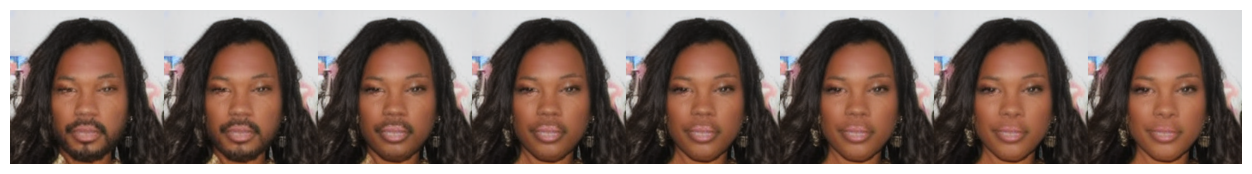

In [154]:
# do intervention (beard, manual seed 10, start from -1, gs lower , more obvious the OOD feature)
inter_id=2
range_len=8
inter_value = torch.from_numpy(np.linspace(-1, 0, num=range_len))
# Do intervention
image_lists = []


noise = torch.randn(1, 4, 32, 32,generator=torch.manual_seed(25)).to(device)
fixed_noise =noise*pipe.scheduler.init_noise_sigma

images = []
#inter_value  = -1   
s_step = 0

for j in range(0,range_len,1):
    interved_image = pipe(
        prompt, 
        num_inference_steps=50, 
        generator=None, 
        image=noise,
        height=256,
        width=256,
        guidance_scale=1.5,
        training=False,
        latents = fixed_noise,
        intervention_indx=inter_id,
        intervention_values=inter_value[j],
        label = torch.tensor([1., 0., 1., 0.]).unsqueeze(0)
    ).images[0]
    image_lists.append(np.asarray(interved_image))
output='./'
save_path = os.path.join(output,'intervention_variable{}.png'.format(inter_id))
save_images_grid([image_lists],(1,range_len),save_path)
